In [1]:
import autosklearn.classification
import sklearn.model_selection
import sklearn.datasets
import sklearn.metrics

print("Auto-sklearn version:", autosklearn.__version__)

Auto-sklearn version: 0.15.0


In [3]:
import pandas as pd

# 1. Load the processed features (X)
X_train = pd.read_csv('X_train_final.csv')
X_test = pd.read_csv('X_test_final.csv')

# 2. Load the processed targets (y)
# Note: Use squeeze() to convert a single-column DataFrame into a Series
y_train = pd.read_csv('y_train_final.csv').squeeze()
y_test = pd.read_csv('y_test_final.csv').squeeze()

print("Data loaded successfully!")
print(f"Training features: {X_train.shape}, Training labels: {y_train.shape}")
print(f"Testing features: {X_test.shape}, Testing labels: {y_test.shape}")

Data loaded successfully!
Training features: (40000, 82), Training labels: (40000,)
Testing features: (10000, 82), Testing labels: (10000,)


In [4]:
import os
import joblib
import autosklearn.classification
import sklearn.metrics

model_filename = 'final_autosklearn_model.pkl'

if os.path.exists(model_filename):
    print(f"--- Found saved model: {model_filename} ---")
    print("Loading model instantly...")
    automl = joblib.load(model_filename)
else:
    print(f"--- {model_filename} not found ---")
    print("Starting 1-hour deep search training...")
    # 3. Configure and Train Auto-Sklearn
    automl = autosklearn.classification.AutoSklearnClassifier()

    automl.fit(X_train, y_train)
    
    # Save it immediately after training
    joblib.dump(automl, model_filename)
    print(f"Training complete. Model saved as {model_filename}")

# 4. Final Comparison Results
predictions = automl.predict(X_test)
accuracy = sklearn.metrics.accuracy_score(y_test, predictions)

print("-" * 30)
print(f"Auto-sklearn Accuracy Score: {accuracy:.4f}")
print("-" * 30)
print(automl.leaderboard())

--- Found saved model: final_autosklearn_model.pkl ---
Loading model instantly...
------------------------------
Auto-sklearn Accuracy Score: 0.9979
------------------------------
          rank  ensemble_weight                type      cost   duration
model_id                                                                
92           1             0.02                 sgd  0.002879  11.644739
97           2             0.02                 sgd  0.002879   5.278131
143          3             0.02                 sgd  0.002955   2.084984
141          4             0.02          libsvm_svc  0.010985  17.858932
112          5             0.02                 sgd  0.012045   2.895547
85           6             0.02                 sgd  0.012121  14.942077
39           7             0.74                 sgd  0.017803   1.754619
44           8             0.02                 mlp  0.027576   3.176109
84           9             0.04                 sgd  0.029924   8.364879
3           10   

In [5]:
print(automl.sprint_statistics())

auto-sklearn results:
  Dataset name: de9a6466-47bd-11f1-800c-dee983cc07c9
  Metric: accuracy
  Best validation score: 0.997121
  Number of target algorithm runs: 143
  Number of successful target algorithm runs: 120
  Number of crashed target algorithm runs: 3
  Number of target algorithms that exceeded the time limit: 4
  Number of target algorithms that exceeded the memory limit: 16



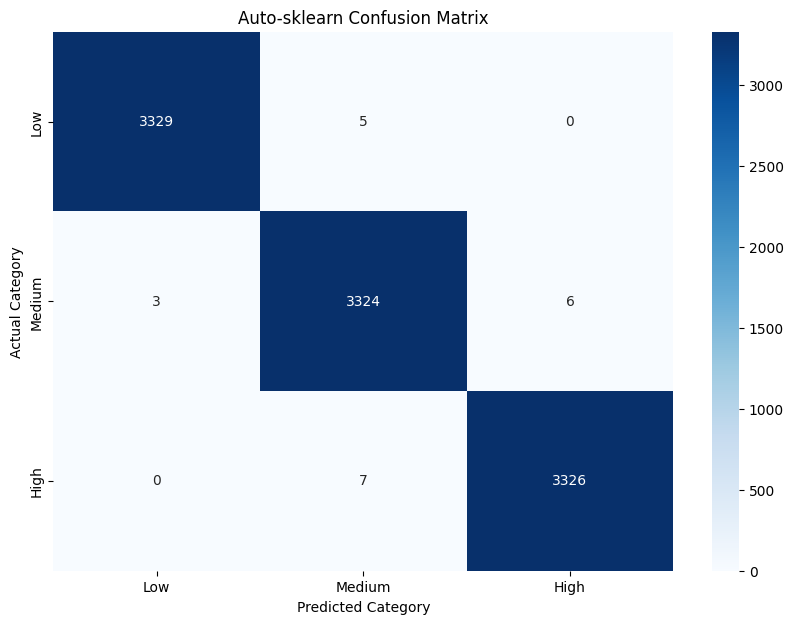


 FINAL ACCURACY: 99.79%

=============== Detailed Classification Report ===============
              precision    recall  f1-score   support

         Low       1.00      1.00      1.00      3334
      Medium       1.00      1.00      1.00      3333
        High       1.00      1.00      1.00      3333

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

class_names = ['Low', 'Medium', 'High']

# 1. Generate the Confusion Matrix
cm = confusion_matrix(y_test, predictions)

# 2. Draw the Confusion Matrix using Seaborn
plt.figure(figsize=(10, 7))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('Auto-sklearn Confusion Matrix')
plt.ylabel('Actual Category')
plt.xlabel('Predicted Category')
plt.show()

# 3. Print Overall Accuracy and Detailed Metrics
acc = accuracy_score(y_test, predictions)

print("\n" + "="*25)
print(f" FINAL ACCURACY: {acc:.2%}")
print("="*25)

print("\n" + "="*15 + " Detailed Classification Report " + "="*15)
print(classification_report(y_test, predictions, target_names=class_names))